<a href="https://colab.research.google.com/github/Harini-Sri-Vedha-Alvar/Fake-Job-Post-Prediction-ML-Project-/blob/main/Fake_Job_Post_Prediction_(ML_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("fake_job_postings.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFraudulent distribution:")
print(df["fraudulent"].value_counts())

print("\nFraudulent percentage:")
print(df["fraudulent"].value_counts(normalize=True) * 100)

Missing values:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Duplicate rows: 0

Fraudulent distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Fraudulent percentage:
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


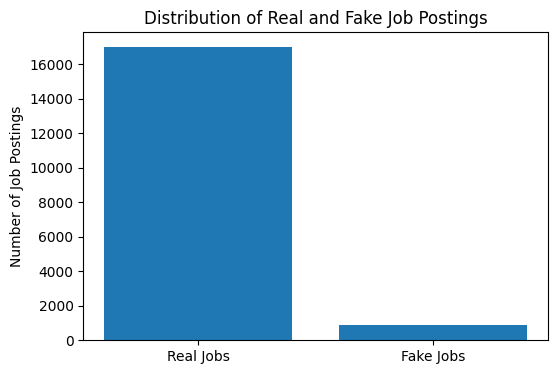

In [ ]:
import matplotlib.pyplot as plt

churn_counts = df["fraudulent"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Real Jobs", "Fake Jobs"], churn_counts.values)
plt.title("Distribution of Real and Fake Job Postings")
plt.ylabel("Number of Job Postings")
plt.show()

In [ ]:
features = ["has_company_logo", "has_questions", "telecommuting"]

for feature in features:
    print(f"\n--- {feature} ---")
    print(
        pd.crosstab(
            df[feature],
            df["fraudulent"],
            normalize="index"
        ).round(3) * 100
    )


--- has_company_logo ---
fraudulent           0     1
has_company_logo            
0                 84.1  15.9
1                 98.0   2.0

--- has_questions ---
fraudulent        0    1
has_questions           
0              93.2  6.8
1              97.2  2.8

--- telecommuting ---
fraudulent        0    1
telecommuting           
0              95.3  4.7
1              91.7  8.3


In [ ]:
pd.crosstab(
    df["employment_type"],
    df["fraudulent"],
    normalize="index"
).round(3) * 100

fraudulent,0,1
employment_type,,
Contract,97.1,2.9
Full-time,95.8,4.2
Other,93.4,6.6
Part-time,90.7,9.3
Temporary,99.2,0.8


In [ ]:
pd.crosstab(
    df["required_experience"],
    df["fraudulent"],
    normalize="index"
).round(3) * 100

fraudulent,0,1
required_experience,,
Associate,98.2,1.8
Director,95.6,4.4
Entry level,93.4,6.6
Executive,92.9,7.1
Internship,97.4,2.6
Mid-Senior level,97.0,3.0
Not Applicable,94.6,5.4


In [ ]:
text_cols = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_cols:
    print(f"{col}:")
    print("Missing:", df[col].isna().sum())
    print("Average characters:", df[col].fillna("").str.len().mean().round(1))
    print()

title:
Missing: 0
Average characters: 28.5

company_profile:
Missing: 3308
Average characters: 620.9

description:
Missing: 1
Average characters: 1218.0

requirements:
Missing: 2696
Average characters: 590.1

benefits:
Missing: 7212
Average characters: 208.9



In [ ]:
text_cols = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

df["combined_text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

print(df["combined_text"].head(2))
print("\nAverage text length:",
      df["combined_text"].str.len().mean().round(1))

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
Name: combined_text, dtype: object

Average text length: 2670.5


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["combined_text"].apply(clean_text)

print(df["clean_text"].head(2))

0    marketing intern we re food and we ve created ...
1    customer service cloud video production second...
Name: clean_text, dtype: object


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_text = tfidf.fit_transform(df["clean_text"])
y = df["fraudulent"]

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (17880, 10000)
